In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)

n = 100

df = pd.DataFrame({
    "Age": np.random.randint(18, 60, n),
    "Income": np.random.randint(20000, 100000, n),
    "Purchase_Amount": np.random.randint(500, 5000, n),
    "Savings": np.random.randint(5000, 50000, n),
    "Credit_Score": np.random.randint(300, 850, n)
})

df["Purchased"] = (
    (df["Purchase_Amount"] > 2000) |
    (df["Age"] < 25)
).astype(int)

df.head()

,Age,Income,Purchase_Amount,Savings,Credit_Score,Purchased
0,56,28392,646,16093,393,0
1,46,50535,3719,23070,752,1
2,32,98603,3411,40777,503,1
3,25,72256,2234,21538,517,1
4,38,55222,2343,15729,773,1


In [2]:
X = df.drop("Purchased", axis=1)
y = df["Purchased"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (100, 5)
Target Shape: (100,)


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

train_test_accuracy = accuracy_score(y_test, predictions)

print("Train-Test Split Accuracy:", round(train_test_accuracy, 4))

Train-Test Split Accuracy: 1.0


In [4]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross-Validation Scores:", cv_scores)
print("Mean CV Accuracy:", round(cv_scores.mean(), 4))
print("Standard Deviation:", round(cv_scores.std(), 4))

Cross-Validation Scores: [0.95 1.   1.   1.   0.95]
Mean CV Accuracy: 0.98
Standard Deviation: 0.0245


In [5]:
comparison = pd.DataFrame({
    "Validation Method": [
        "Train-Test Split",
        "5-Fold Cross-Validation"
    ],
    "Mean Accuracy": [
        train_test_accuracy,
        cv_scores.mean()
    ],
    "Standard Deviation": [
        0,
        cv_scores.std()
    ]
})

comparison

,Validation Method,Mean Accuracy,Standard Deviation
0,Train-Test Split,1.00,0.000000
1,5-Fold Cross-Validation,0.98,0.024495


In [6]:
comparison.to_csv("day25_cross_validation_comparison.csv", index=False)

print("Cross-validation comparison report saved successfully!")


Cross-validation comparison report saved successfully!


In [7]:
print("Dataset Shape:", df.shape)

print("\nTrain-Test Accuracy:", round(train_test_accuracy, 4))

print("\nCross-Validation Scores:", cv_scores)
print("Mean CV Accuracy:", round(cv_scores.mean(), 4))
print("Standard Deviation:", round(cv_scores.std(), 4))

print("\nPerformance Comparison:")
print(comparison)

print("\nDay 25 files:")
print("✓ day25_cross_validation.ipynb")
print("✓ day25_cross_validation_comparison.csv")

Dataset Shape: (100, 6)

Train-Test Accuracy: 1.0

Cross-Validation Scores: [0.95 1.   1.   1.   0.95]
Mean CV Accuracy: 0.98
Standard Deviation: 0.0245

Performance Comparison:
         Validation Method  Mean Accuracy  Standard Deviation
0         Train-Test Split           1.00            0.000000
1  5-Fold Cross-Validation           0.98            0.024495

Day 25 files:
✓ day25_cross_validation.ipynb
✓ day25_cross_validation_comparison.csv


In [8]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logistic_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000)
)

logistic_scores = cross_val_score(
    logistic_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Logistic Regression CV Scores:", logistic_scores)
print("Mean CV Accuracy:", round(logistic_scores.mean(), 4))
print("Standard Deviation:", round(logistic_scores.std(), 4))

Logistic Regression CV Scores: [0.95 0.95 0.95 1.   0.9 ]
Mean CV Accuracy: 0.95
Standard Deviation: 0.0316


In [9]:
model_comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Logistic Regression"
    ],
    "Mean CV Accuracy": [
        cv_scores.mean(),
        logistic_scores.mean()
    ],
    "Standard Deviation": [
        cv_scores.std(),
        logistic_scores.std()
    ]
})

model_comparison["Min CV Score"] = [
    cv_scores.min(),
    logistic_scores.min()
]

model_comparison["Max CV Score"] = [
    cv_scores.max(),
    logistic_scores.max()
]

print(model_comparison)

                 Model  Mean CV Accuracy  Standard Deviation  Min CV Score  \
0        Random Forest              0.98            0.024495          0.95   
1  Logistic Regression              0.95            0.031623          0.90   

   Max CV Score  
0           1.0  
1           1.0  


In [10]:
model_comparison.to_csv(
    "day25_model_cv_comparison.csv",
    index=False
)

print("Model cross-validation report saved successfully!")

Model cross-validation report saved successfully!


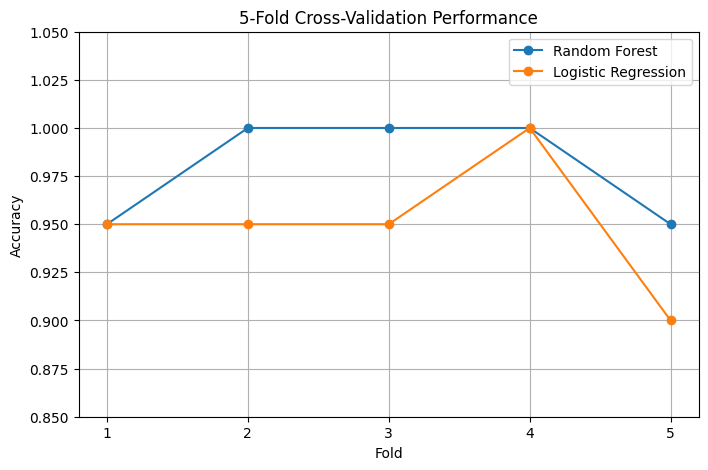

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 6),
    cv_scores,
    marker="o",
    label="Random Forest"
)

plt.plot(
    range(1, 6),
    logistic_scores,
    marker="o",
    label="Logistic Regression"
)

plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("5-Fold Cross-Validation Performance")
plt.xticks(range(1, 6))
plt.ylim(0.85, 1.05)
plt.legend()
plt.grid(True)

plt.show()